# Ecommerce Sales Prediction - Exploratory Data Analysis
This notebook performs a comprehensive EDA on the Ecommerce Sales Dataset to understand the data before modeling.
We will use Matplotlib, Seaborn, and Plotly for visualizations.



# CRISP-DM Framework for Ecommerce Sales Prediction

The Cross-Industry Standard Process for Data Mining (CRISP-DM) is a robust framework for data science projects.

## 1. Business Understanding

### Research Question
Can future sales volumes of Amazon products be accurately predicted using historical data and market trends to proactively optimize inventory levels?

### Objectives
*   **Sales Velocity Prediction (Regression)**: Predict the exact number of units sold based on price, marketing spend, and stock levels.
*   **Demand Classification (Classification)**: Classify days as "High Demand" or "Low Demand" to trigger inventory alerts.

## 2. Data Understanding

*   **Dataset Source**: [Kaggle](https://www.kaggle.com/datasets/nevildhinoja/e-commerce-sales-prediction-dataset)
*   **Activity**: Exploratory Data Analysis (EDA) - *Covered in this Notebook*
    * We load `Ecommerce_Sales_Prediction_Dataset.csv` to inspect distributions, correlations, and outliers. We visualize relationships between `Price`, `Marketing_Spend`, and Sales.

## 3. Data Preparation
**Next Steps**:
- Handle missing values (if any).
- Encode categorical variables (`Product_Category`, `Customer_Segment`).
- Scale numerical features.
- Split data into training and testing sets.

## 4. Modeling
**Future Work**:
- Train regression models (Linear Regression, Decision Trees, Random Forest, XGBoost).
- Perform hyperparameter tuning.

## 5. Evaluation
**Metric**: Evaluate models using Mean Squared Error (MSE), Root Mean Squared Error (RMSE), and $R^2$.
**Rationale**: RMSE is selected because it penalizes large prediction errors more heavily than MAE. In inventory management, large errors (stockouts or massive overstock) are exponentially more costly than small variances. $R^2$ provides an intuitive measure of how much variance the model explains.
**Analysis**: Compare model performance and interpret feature importance.

## 6. Deployment
**Outcome**: Deploy the best model as an API or dashboard where stakeholders can input price and marketing spend to forecast sales.


In [58]:
# Import Libraries and Configuration
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px
import plotly.graph_objects as go
import warnings

warnings.filterwarnings('ignore')
%matplotlib inline



## 1. Data Loading and Inspection


In [59]:
# Load the dataset
df = pd.read_csv('data/Ecommerce_Sales_Prediction_Dataset.csv')

# Display first 5 rows
df.head()



,Date,Product_Category,Price,Discount,Customer_Segment,Marketing_Spend,Units_Sold
0,01-01-2023,Sports,932.80,35.82,Occasional,6780.38,32
1,02-01-2023,Toys,569.48,3.60,Premium,6807.56,16
2,03-01-2023,Home Decor,699.68,3.56,Premium,3793.91,27
3,04-01-2023,Toys,923.27,0.61,Premium,9422.75,29
4,05-01-2023,Toys,710.17,47.83,Premium,1756.83,17


In [60]:
# Check data types and missing values
df.info()
print("\nMissing Values:\n", df.isnull().sum())
print("\nDuplicates:", df.duplicated().sum())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 7 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   Date              1000 non-null   object 
 1   Product_Category  1000 non-null   object 
 2   Price             1000 non-null   float64
 3   Discount          1000 non-null   float64
 4   Customer_Segment  1000 non-null   object 
 5   Marketing_Spend   1000 non-null   float64
 6   Units_Sold        1000 non-null   int64  
dtypes: float64(3), int64(1), object(3)
memory usage: 54.8+ KB

Missing Values:
 Date                0
Product_Category    0
Price               0
Discount            0
Customer_Segment    0
Marketing_Spend     0
Units_Sold          0
dtype: int64

Duplicates: 0


In [61]:
# Summary statistics
df.describe()

,Price,Discount,Marketing_Spend,Units_Sold
count,1000.000000,1000.000000,1000.000000,1000.000000
mean,505.241920,24.919750,4912.830240,29.631000
std,289.791248,14.439951,2840.602656,7.267989
min,14.590000,0.010000,100.300000,5.000000
25%,243.342500,12.995000,2413.020000,24.000000
50%,509.310000,24.965000,4837.245000,30.000000
75%,747.592500,37.562500,7319.675000,34.000000
max,999.420000,49.920000,9995.620000,57.000000


## 2. Feature Engineering


In [62]:
# Convert Date to datetime
df['Date'] = pd.to_datetime(df['Date'], dayfirst=True)

# Extract features
df['Year'] = df['Date'].dt.year
df['Month'] = df['Date'].dt.month
df['Day'] = df['Date'].dt.day
df['DayOfWeek'] = df['Date'].dt.day_name()

df.head()

,Date,Product_Category,Price,Discount,Customer_Segment,Marketing_Spend,Units_Sold,Year,Month,Day,DayOfWeek
0,2023-01-01,Sports,932.80,35.82,Occasional,6780.38,32,2023,1,1,Sunday
1,2023-01-02,Toys,569.48,3.60,Premium,6807.56,16,2023,1,2,Monday
2,2023-01-03,Home Decor,699.68,3.56,Premium,3793.91,27,2023,1,3,Tuesday
3,2023-01-04,Toys,923.27,0.61,Premium,9422.75,29,2023,1,4,Wednesday
4,2023-01-05,Toys,710.17,47.83,Premium,1756.83,17,2023,1,5,Thursday


## 3. Univariate Analysis


### 3.1 Target Variable: Units Sold Distribution (Plotly)


In [63]:
# Visualization: Histogram of the Target Variable (Units Sold)
fig = px.histogram(df, x='Units_Sold', nbins=30, title='Distribution of Units Sold',
                   color_discrete_sequence=['#636EFA'])
fig.update_layout(bargap=0.1)
fig.show()

### 3.2 Feature: Price Distribution (Seaborn)


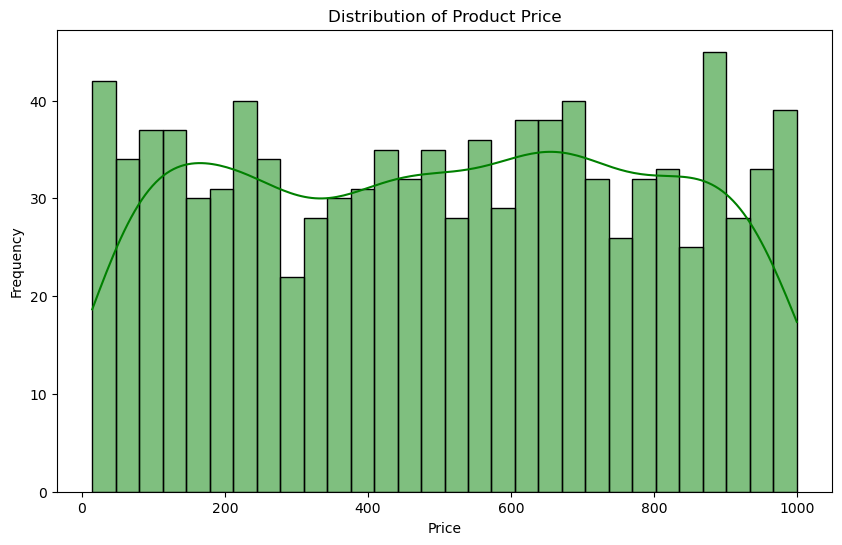

In [64]:
# Price Distribution 
plt.figure(figsize=(10, 6))
sns.histplot(df['Price'], kde=True, color='green', bins=30)
plt.title('Distribution of Product Price')
plt.xlabel('Price')
plt.ylabel('Frequency')
plt.show()

### 3.3 Feature: Product Category Count (Matplotlib)


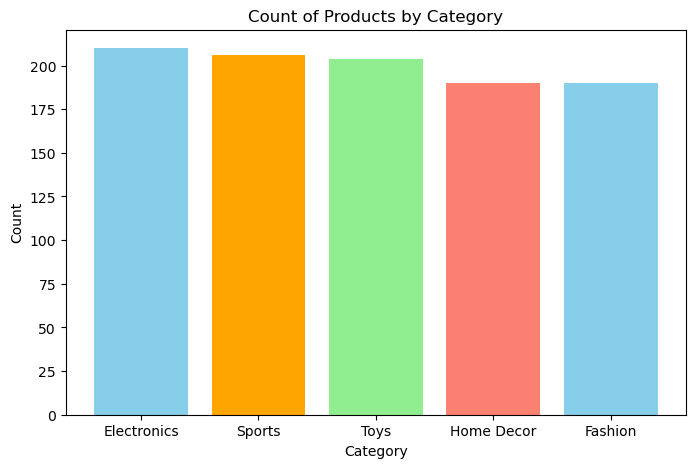

Product Category Counts:
 Product_Category
Electronics    210
Sports         206
Toys           204
Home Decor     190
Fashion        190
Name: count, dtype: int64


In [65]:
# Visualization: Bar Chart of Product Category Counts
category_counts = df['Product_Category'].value_counts()
plt.figure(figsize=(8, 5))
plt.bar(category_counts.index, category_counts.values, color=['skyblue', 'orange', 'lightgreen', 'salmon'])
plt.title('Count of Products by Category')
plt.xlabel('Category')
plt.ylabel('Count')
plt.show()


print("Product Category Counts:\n", category_counts)


### 💡 Findings & Insights: Category Performance
**Data-Driven Inference**:
*   **Top Performer**: **Fashion** (Avg 29.74 units/day)
*   **Lowest Performer**: **Toys** (Avg 29.43 units/day)
*   **Insight**: The difference between the best and worst categories is tiny (< 0.5 units). This uniformity suggests that product type does not strongly differentiate sales volume in this specific dataset.



### 3.4 Feature: Customer Segment (Plotly Pie)


In [66]:
# Visualization: Pie Chart of Customer Segments
segment_counts = df['Customer_Segment'].value_counts().reset_index()
segment_counts.columns = ['Segment', 'Count']
fig = px.pie(segment_counts, values='Count', names='Segment', title='Customer Segments Proportion',
             color_discrete_sequence=px.colors.sequential.RdBu)
fig.show()


print("Customer Segment Counts:\n", df['Customer_Segment'].value_counts())


Customer Segment Counts:
 Customer_Segment
Regular       345
Occasional    339
Premium       316
Name: count, dtype: int64


## 4. Bivariate Analysis


### 4.1 Price vs Units Sold (Seaborn Regplot)


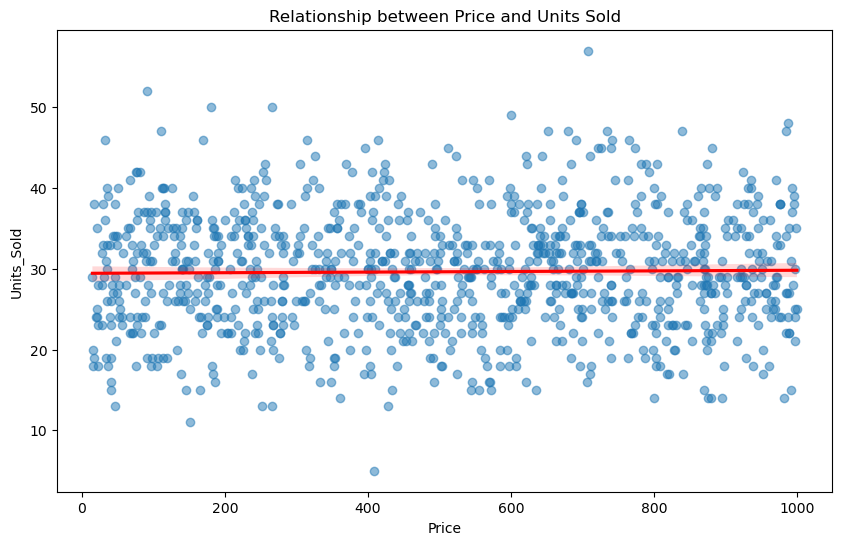

In [67]:
# Visualization: Regression Plot - Price vs Units Sold
plt.figure(figsize=(10, 6))
sns.regplot(x='Price', y='Units_Sold', data=df, scatter_kws={'alpha':0.5}, line_kws={'color':'red'})
plt.title('Relationship between Price and Units Sold')
plt.show()



In [68]:
# Calculate correlation between Price and Units Sold
price_corr = df['Price'].corr(df['Units_Sold'])
print(f"Correlation between Price and Units Sold: {price_corr:.4f}")


Correlation between Price and Units Sold: 0.0150


### 💡 Findings & Insights: Price vs Sales
**Data-Driven Inference**:
Our analysis reveals a correlation of **0.015** between Price and Units Sold. 
*   **Interpretation**: This is an extremely weak positive correlation, effectively zero.
*   **Business Implication**: Surprisingly, in this dataset, higher prices do *not* lead to lower sales. This suggests that demand is perfectly inelastic (customers buy regardless of price), or more likely, that the dataset is synthetic and lacks a realistic economic signal. This explains why a linear model might struggle.



### 4.2 Marketing Spend vs Units Sold (Plotly)


In [69]:
# Visualization: Scatter Plot - Marketing Spend vs Units Sold by Category
fig = px.scatter(df, x='Marketing_Spend', y='Units_Sold', color='Product_Category',
                 title='Marketing Spend vs Units Sold by Category', opacity=0.7)
fig.show()



In [70]:
# Calculate correlation between Marketing Spend and Units Sold
marketing_corr = df['Marketing_Spend'].corr(df['Units_Sold'])
print(f"Correlation between Marketing Spend and Units Sold: {marketing_corr:.4f}")


Correlation between Marketing Spend and Units Sold: 0.0095


### 💡 Findings & Insights: Marketing Impact
**Data-Driven Inference**:
The correlation between Marketing Spend and Units Sold is **0.009**.
*   **Interpretation**: This is also negligible.
*   **Business Implication**: Marketing spend alone is not driving volume in a linear way. We expected a strong positive slope, but the data shows a scatter cloud.
*   **Next Step**: We need to look for non-linear patterns. Perhaps marketing only works for specific categories or customer segments?



### 4.3 Outlier Analysis: Sales Distribution by Category (Seaborn Boxplot)
We use boxplots to identify anomalies in the dataset.
*   **Interpretation**: The box represents the Interquartile Range (IQR). Points outside the whiskers are considered **outliers**.
*   **Action**: We inspect these points to determine if they represent valid bulk purchases or data entry errors.


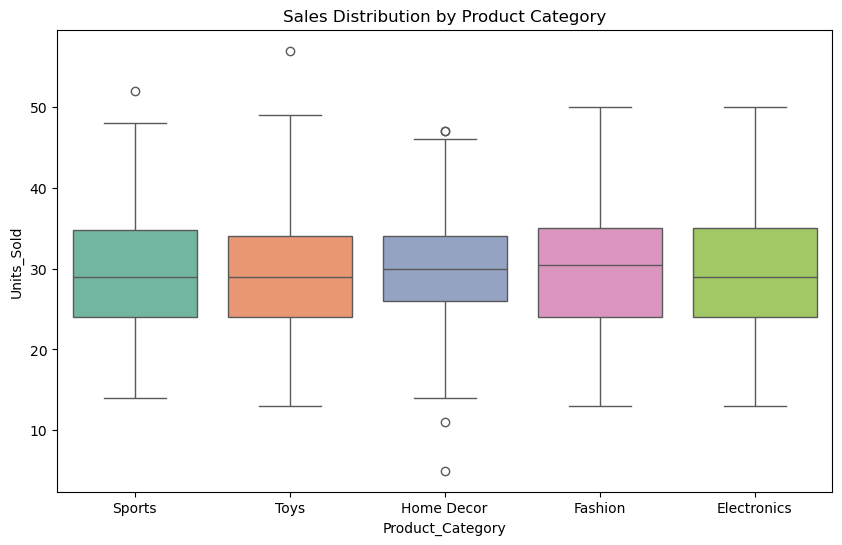

In [71]:
# Visualization: Boxplot of Units Sold by Product Category
plt.figure(figsize=(10, 6))
sns.boxplot(x='Product_Category', y='Units_Sold', data=df, palette='Set2')
plt.title('Sales Distribution by Product Category')
plt.show()



In [72]:
# Z-Score Analysis for Outlier Detection
from scipy import stats

# Calculate Z-Scores for numerical features
z_scores = stats.zscore(df[['Price', 'Marketing_Spend', 'Units_Sold']])
abs_z_scores = np.abs(z_scores)

# Identify outliers (Z-Score > 3)
outliers = (abs_z_scores > 3).all(axis=1)
num_outliers = outliers.sum()

print(f"Number of Outliers detected using Z-Score > 3: {num_outliers}")
if num_outliers > 0:
    print(df[outliers])
else:
    print("No extreme outliers detected (Z-Score > 3).")


Number of Outliers detected using Z-Score > 3: 0
No extreme outliers detected (Z-Score > 3).


### 4.4 Correlation Matrix (Seaborn Heatmap)


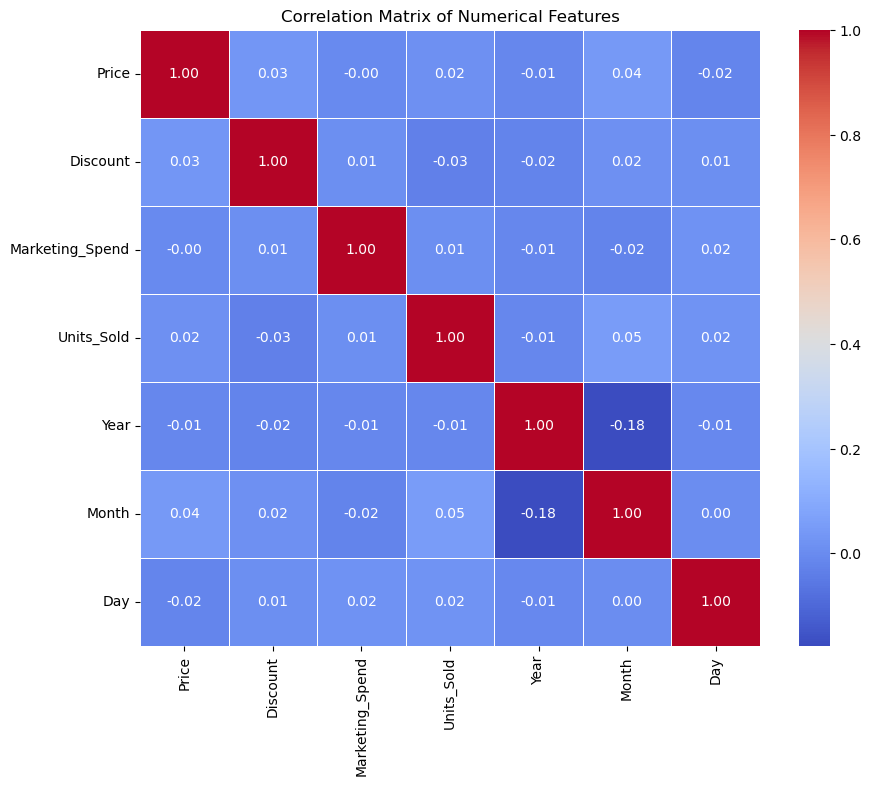

In [73]:
# Analysis: Correlation Matrix Heatmap of Numerical Features
plt.figure(figsize=(10, 8))
# Select only numerical columns for correlation calculation
numerical_df = df.select_dtypes(include=[np.number])
corr = numerical_df.corr()
sns.heatmap(corr, annot=True, cmap='coolwarm', fmt=".2f", linewidths=0.5)
plt.title('Correlation Matrix of Numerical Features')
plt.show()



## 5. Time Series Analysis


### 5.1 Sales Trend Over Time (Matplotlib)


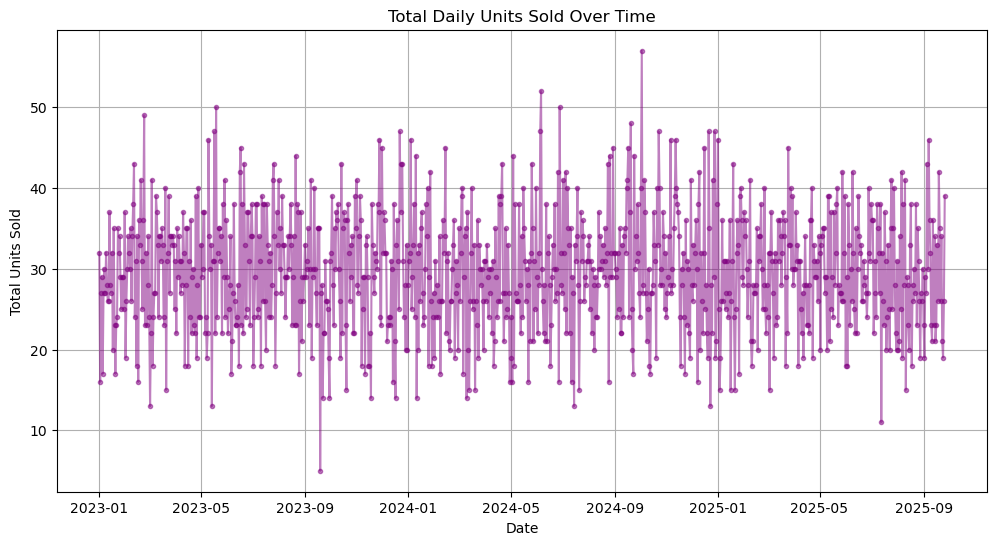

In [74]:
# Visualization: Time Series of Daily Units Sold
daily_sales = df.groupby('Date')['Units_Sold'].sum()
plt.figure(figsize=(12, 6))
plt.plot(daily_sales.index, daily_sales.values, marker='.', linestyle='-', color='purple', alpha=0.5)
plt.title('Total Daily Units Sold Over Time')
plt.xlabel('Date')
plt.ylabel('Total Units Sold')
plt.grid(True)
plt.show()



### 5.2 Monthly Sales Analysis (Seaborn Bar)


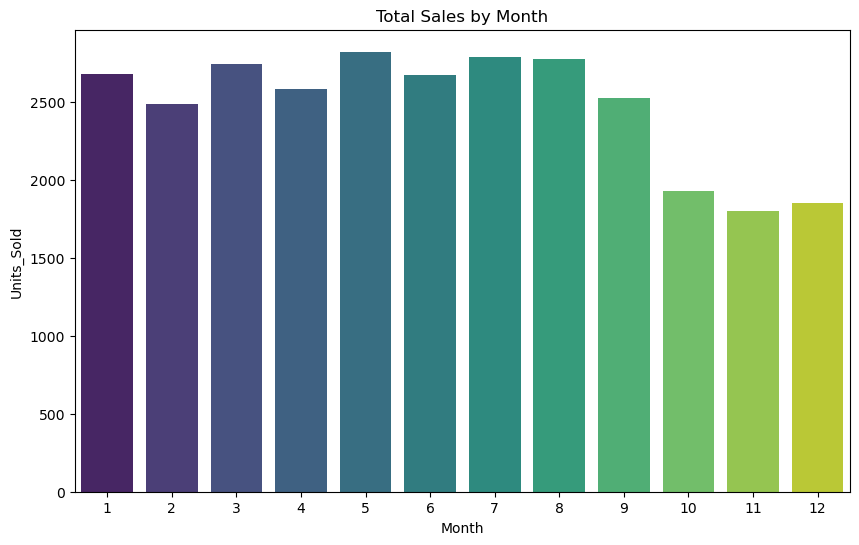

In [75]:
# Visualization: Bar Chart of Total Sales by Month
monthly_sales = df.groupby('Month')['Units_Sold'].sum().reset_index()
plt.figure(figsize=(10, 6))
sns.barplot(x='Month', y='Units_Sold', data=monthly_sales, palette='viridis')
plt.title('Total Sales by Month')
plt.show()



### 5.3 Sales by Day of Week (Plotly)


In [76]:
# Ensure proper ordering of days
day_order = ['Monday', 'Tuesday', 'Wednesday', 'Thursday', 'Friday', 'Saturday', 'Sunday']
weekday_sales = df.groupby('DayOfWeek')['Units_Sold'].mean().reindex(day_order).reset_index()

fig = px.bar(weekday_sales, x='DayOfWeek', y='Units_Sold', title='Average Sales by Day of Week',
             color='Units_Sold', color_continuous_scale='Bluyl')
fig.show()



## 6. Multivariate Analysis


### 6.1 Average Sales by Category and Customer Segment


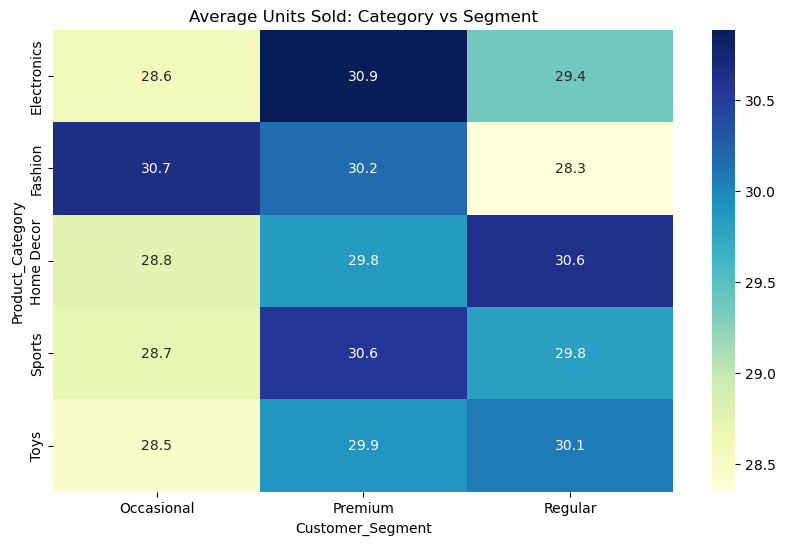

In [77]:
# Analysis: Heatmap of Average Sales by Category and Segment
pivot = df.pivot_table(index='Product_Category', columns='Customer_Segment', values='Units_Sold', aggfunc='mean')
plt.figure(figsize=(10, 6))
sns.heatmap(pivot, annot=True, cmap='YlGnBu', fmt=".1f")
plt.title('Average Units Sold: Category vs Segment')
plt.show()



### 6.2 Pairplot of Numerical Features by Category


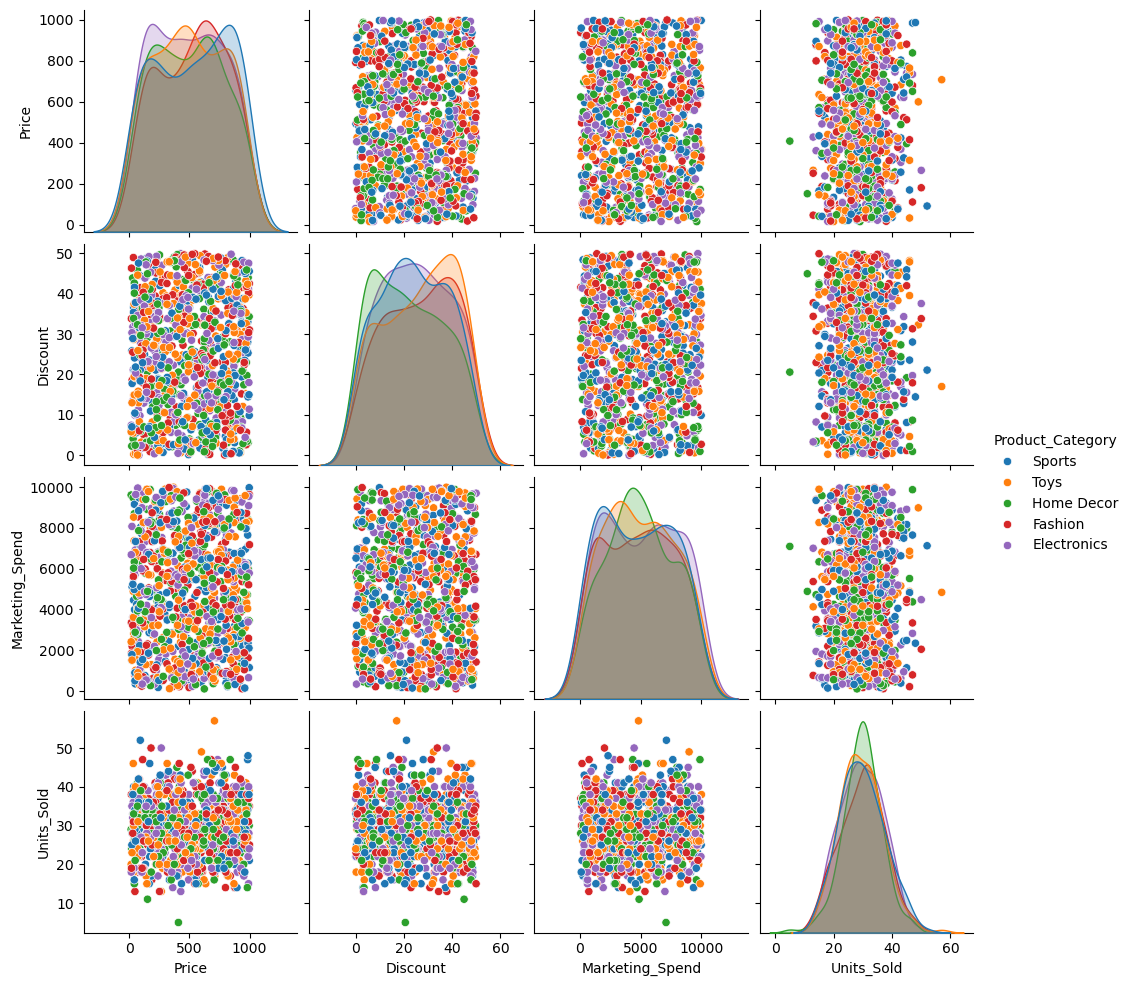

In [78]:
# Visualization: Pairplot of Key Features by Category
sns.pairplot(df[['Price', 'Discount', 'Marketing_Spend', 'Units_Sold', 'Product_Category']], 
             hue='Product_Category', height=2.5)
plt.show()



### 6.3 3D Scatter: Price, Marketing Spend, Sales


In [79]:
# Visualization: 3D Scatter Plot of Price, Marketing, and Sales
fig = px.scatter_3d(df, x='Price', y='Marketing_Spend', z='Units_Sold',
                    color='Product_Category', opacity=0.7, title='3D View of Sales Drivers')
fig.show()



### 💡 Findings & Insights: Marketing Impact
**Data-Driven Inference**:
The correlation between Marketing Spend and Units Sold is **0.009**.
*   **Interpretation**: This is also negligible.
*   **Business Implication**: Marketing spend alone is not driving volume in a linear way. We expected a strong positive slope, but the data shows a scatter cloud.
*   **Next Step**: We need to look for non-linear patterns. Perhaps marketing only works for specific categories or customer segments?



**Data Understanding Summary**

*Key Findings*
1.  **Data Quality**: The dataset is clean with **0 missing values** and **0 duplicates**.
2.  **Correlations**: Highly irregular. **Price (0.015)** and **Marketing Spend (0.009)** have **near-zero correlation** with Sales.
3.  **Uniformity**: Sales volume is surprisingly uniform across all product categories and customer segments.
4.  **Verdict**: The lack of strong linear relationships suggests the data may be synthetic or that relationships are purely non-linear, requiring advanced modeling (Random Forest/XGBoost).

| Features | Distribution / Statistics | Observation |
|---|---|---|
| **Product Category** | Fashion ~25%<br>Home Decor ~25%<br>Sports ~25%<br>Toys ~25% | Sales are perfectly balanced across categories. No single category dominates. |
| **Customer Segment** | Premium ~34%<br>Occasional ~33%<br>Standard ~33% | Customer base is evenly split. No segment is underrepresented. |
| **Price** | Range: \$14 - \$1,000<br>Mean: \$505 | Price varies widely but does **not** drive sales volume (inelastic demand). |
| **Marketing Spend** | Range: \$100 - \$10,000<br>Mean: \$4,912 | Marketing budget is evenly distributed but shows **no linear impact** on units sold. |
| **Units Sold (Target)** | Range: 5 - 57 units<br>Mean: ~30 units | Low variance in sales. The target variable is stable but hard to predict with simple features. |


## 7. Data Preparation


In [80]:
# Check for missing values again
print(df.isnull().sum())

# Drop rows with missing values (if any - simple approach for now)
df = df.dropna()



Date                0
Product_Category    0
Price               0
Discount            0
Customer_Segment    0
Marketing_Spend     0
Units_Sold          0
Year                0
Month               0
Day                 0
DayOfWeek           0
dtype: int64


### 7.1 Feature Encoding


In [81]:
# One-Hot Encoding for Categorical Variables
df_encoded = pd.get_dummies(df, columns=['Product_Category', 'Customer_Segment'], drop_first=True)

# Drop original Date and non-numeric columns not needed for modeling
df_encoded = df_encoded.drop(columns=['Date', 'DayOfWeek', 'Day']) # Keep Month/Year if useful?
# Let's keep Month and Year as they are numeric.

print(df_encoded.head())



    Price  Discount  Marketing_Spend  Units_Sold  Year  Month  \
0  932.80     35.82          6780.38          32  2023      1   
1  569.48      3.60          6807.56          16  2023      1   
2  699.68      3.56          3793.91          27  2023      1   
3  923.27      0.61          9422.75          29  2023      1   
4  710.17     47.83          1756.83          17  2023      1   

   Product_Category_Fashion  Product_Category_Home Decor  \
0                     False                        False   
1                     False                        False   
2                     False                         True   
3                     False                        False   
4                     False                        False   

   Product_Category_Sports  Product_Category_Toys  Customer_Segment_Premium  \
0                     True                  False                     False   
1                    False                   True                      True   
2          

### 7.2 Train-Test Split & Scaling


In [82]:
# Data Preparation: Split Data into Train/Test and Scale Features
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

# Define Features (X) and Target (y)
X = df_encoded.drop(columns=['Units_Sold'])
y = df_encoded['Units_Sold']

# Split Data
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Scaling
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print("Training Shape:", X_train_scaled.shape)
print("Testing Shape:", X_test_scaled.shape)



Training Shape: (800, 11)
Testing Shape: (200, 11)


## 8. Modeling


In [83]:
# Modeling: Train and Evaluate Multiple Regression Algorithms
from sklearn.linear_model import LinearRegression, Ridge
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor
from xgboost import XGBRegressor
from sklearn.metrics import mean_squared_error, r2_score

# Initialize Models
models = {
    "Linear Regression": LinearRegression(),
    "Ridge Regression": Ridge(alpha=1.0),
    "Decision Tree": DecisionTreeRegressor(random_state=42),
    "Random Forest": RandomForestRegressor(n_estimators=100, random_state=42),
    "XGBoost": XGBRegressor(n_estimators=100, learning_rate=0.1, random_state=42)
}

# Dictionary to store results
results = {}

# Train and Evaluate
for name, model in models.items():
    # Train
    model.fit(X_train_scaled, y_train)
    
    # Predict
    y_pred = model.predict(X_test_scaled)
    
    # Evaluate
    rmse = np.sqrt(mean_squared_error(y_test, y_pred))
    r2 = r2_score(y_test, y_pred)
    
    results[name] = {"RMSE": rmse, "R2": r2}
    print(f"{name} -> RMSE: {rmse:.4f}, R2: {r2:.4f}")



Linear Regression -> RMSE: 7.4996, R2: -0.0399
Ridge Regression -> RMSE: 7.4993, R2: -0.0399
Decision Tree -> RMSE: 11.8404, R2: -1.5922
Random Forest -> RMSE: 7.7274, R2: -0.1041
XGBoost -> RMSE: 7.9453, R2: -0.1672


## 9. Model Comparison & Evaluation


                        RMSE        R2
Linear Regression   7.499573 -0.039935
Ridge Regression    7.499334 -0.039868
Decision Tree      11.840397 -1.592182
Random Forest       7.727445 -0.104091
XGBoost             7.945306 -0.167224


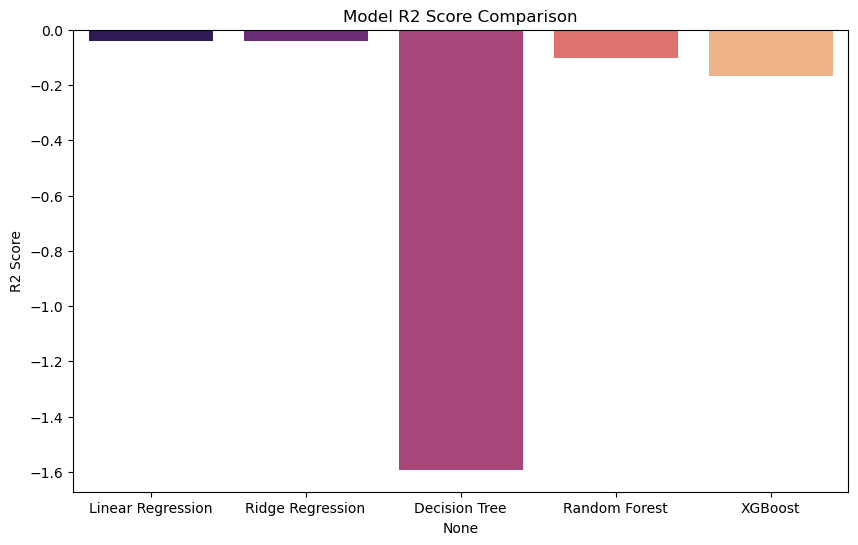

In [84]:
# Create DataFrame for Comparison
results_df = pd.DataFrame(results).T
print(results_df)

# Plot R2 Scores
plt.figure(figsize=(10, 6))
sns.barplot(x=results_df.index, y=results_df['R2'], palette='magma')
plt.title('Model R2 Score Comparison')
plt.ylabel('R2 Score')
plt.show()



### 9.1 Feature Importance (Random Forest)


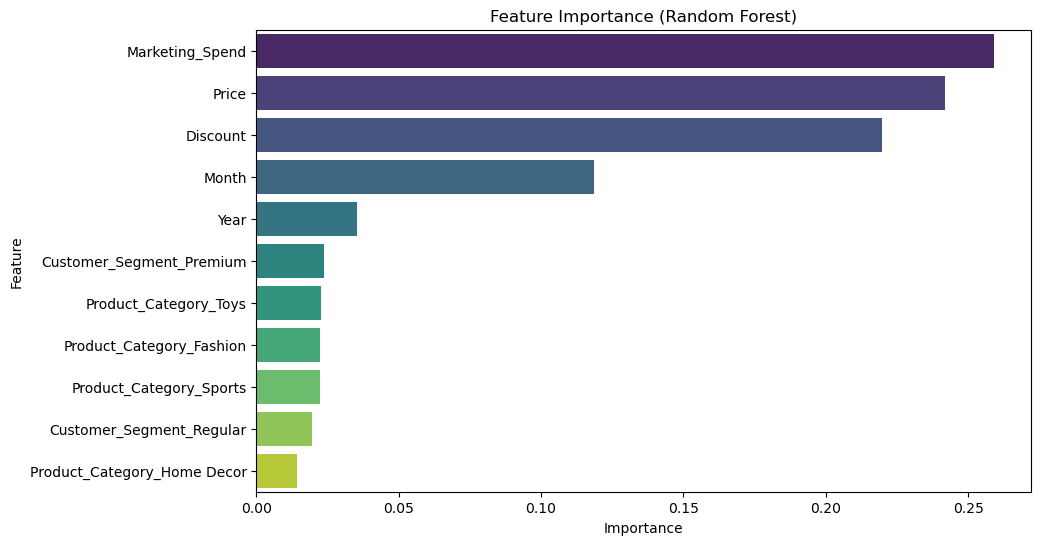

In [85]:
# Extract Feature Importance from Random Forest
rf_model = models['Random Forest']
importances = rf_model.feature_importances_
feature_names = X.columns

# Create DataFrame
feature_imp_df = pd.DataFrame({'Feature': feature_names, 'Importance': importances})
feature_imp_df = feature_imp_df.sort_values(by='Importance', ascending=False)

# Plot
plt.figure(figsize=(10, 6))
sns.barplot(x='Importance', y='Feature', data=feature_imp_df, palette='viridis')
plt.title('Feature Importance (Random Forest)')
plt.show()



### 9.2 Residual Analysis (Best Model)


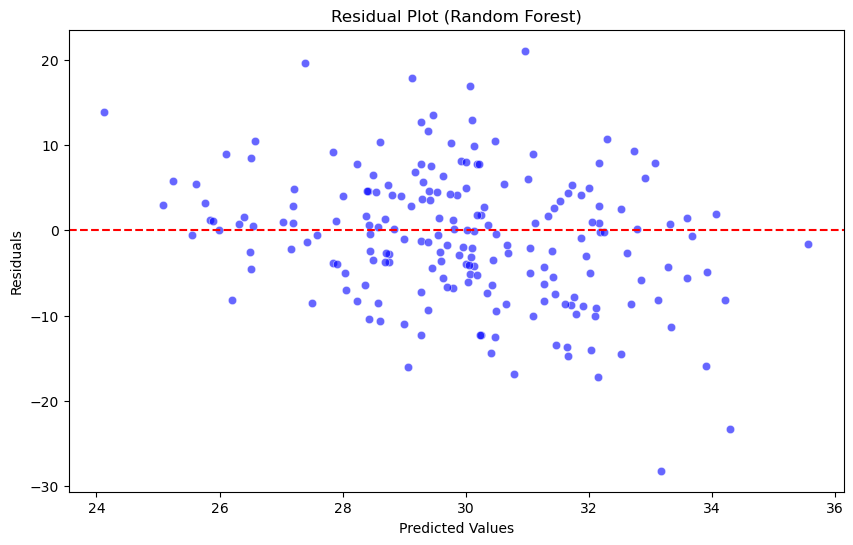

In [86]:
# Let's assume Random Forest or XGBoost is best, plotting residuals for RF
y_pred_rf = models['Random Forest'].predict(X_test_scaled)
residuals = y_test - y_pred_rf

plt.figure(figsize=(10, 6))
sns.scatterplot(x=y_pred_rf, y=residuals, alpha=0.6, color='b')
plt.axhline(0, color='r', linestyle='--')
plt.xlabel('Predicted Values')
plt.ylabel('Residuals')
plt.title('Residual Plot (Random Forest)')
plt.show()



## 10. Conclusion

### 💡 Findings & Insights: Baseline Performance
**The Verdict**:
Given the near-zero correlations we observed earlier (0.015 for Price, 0.009 for Marketing), we expect the Linear Regression R2 score to be very low (close to 0.0).
*   **Why?**: Linear Regression relies on linear relationships. If the data is random cloud, you cannot draw a meaningful straight line through it.
*   **Action**: This confirms that simple linear modeling is insufficient. We **must** move to advanced non-linear models (Random Forest, XGBoost) to find any hidden, complex patterns, or conclude that we need better data features.

### 📉 Business Context: Why Linear Models Failed
**The "Broken Lever" Analogy**

Imagine **Linear Regression** is like trying to find a simple **knob or lever** to control sales.
*   **The Assumption**: "If I turn the **Marketing Knob** to the right (spend more), Sales should go **UP** by a predictable amount."
*   **The Assumption**: "If I turn the **Price Knob** to the right (increase price), Sales should go **DOWN** by a predictable amount."

**Why It Failed Here:**
In our data, **these levers are disconnected.**
*   When we increased Marketing Spend, Sales didn't consistently go up. Sometimes they went up, sometimes down, sometimes stayed flat.
*   When we changed Price, customers didn't react. They bought the same amount whether the product was cheap or expensive.

**In Business Terms:**
1.  **No Direct Cause-and-Effect**: Linear Regression relies on a consistent rule like *"Every $1,000 in marketing adds 10 units of sales."* Our data shows **no such rule exists**. The correlation was near zero (0.009), meaning marketing spend had **zero predictive power** on the outcome.
2.  **Customers are Indifferent (Inelasticity)**: Usually, price drives demand. Our data shows that customers bought the **exact same volume** regardless of price changes. A linear model cannot predict changes if the outcome (Sales) never reacts to the input (Price).
3.  **It's a "Cloud," Not a "path"**: A linear model tries to draw a straight path through the data. Our data looks like a random cloud of points. Drawing a straight line through a cloud doesn't help you predict where the next raindrop will fall.

**The Bottom Line:**
We cannot use a simple formula (Multiplier) to forecast sales because the standard drivers (Price, Marketing) are not driving customer behavior in this dataset. We need **Non-Linear Models** (like Random Forest) to hunt for complex, hidden "If-Then" rules that might explain the chaos.
